In [1]:
import pandas as pd

df = pd.read_csv("FB_GOOG_Historical_Prices_2015_2016.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head(6)

,date,FB,GOOG
0,2015-01-02,78.45,524.81
1,2015-01-05,77.19,513.87
2,2015-01-06,76.15,501.96
3,2015-01-07,76.15,501.10
4,2015-01-08,78.18,502.68
5,2015-01-09,77.74,496.17


In [2]:
# Task1: Calculate the daily returns for both FB and GOOG stocks. Compute the mean and standard deviation of these daily returns

df["FB_return"] = df["FB"].pct_change()
df["GOOG_return"] = df["GOOG"].pct_change()

returns = df.dropna()

fb_mean = returns["FB_return"].mean()
fb_std  = returns["FB_return"].std()

goog_mean = returns["GOOG_return"].mean()
goog_std  = returns["GOOG_return"].std()

print("FB daily return:   mean =", fb_mean,  " std =", fb_std)
print("GOOG daily return: mean =", goog_mean, " std =", goog_std)

FB daily return:   mean = 0.0009045706094875624  std = 0.01705047204350011
GOOG daily return: mean = 0.0008903930946407605  std = 0.01589447145219606


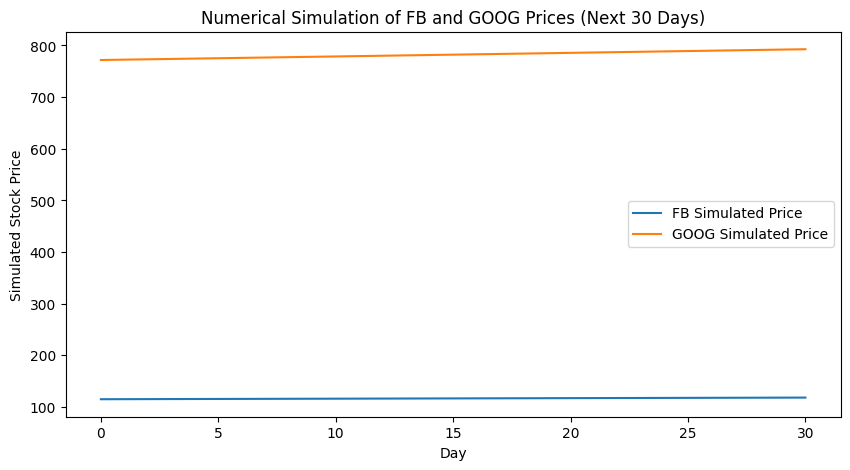

Simulated stock prices for each day:
    Day    FB Price  GOOG Price
0     0  115.050000  771.820000
1     1  115.154071  772.507223
2     2  115.258236  773.195058
3     3  115.362495  773.883506
4     4  115.466849  774.572566
5     5  115.571296  775.262240
6     6  115.675839  775.952529
7     7  115.780476  776.643431
8     8  115.885207  777.334949
9     9  115.990034  778.027083
10   10  116.094955  778.719833
11   11  116.199971  779.413200
12   12  116.305082  780.107184
13   13  116.410288  780.801786
14   14  116.515590  781.497006
15   15  116.620986  782.192846
16   16  116.726478  782.889305
17   17  116.832065  783.586384
18   18  116.937748  784.284084
19   19  117.043527  784.982405
20   20  117.149401  785.681348
21   21  117.255371  786.380913
22   22  117.361437  787.081102
23   23  117.467598  787.781913
24   24  117.573856  788.483349
25   25  117.680210  789.185409
26   26  117.786660  789.888094
27   27  117.893206  790.591405
28   28  117.999849  791.295342
29 

In [3]:
# Task2: Simulate the future price of FB nd GOOG stocks over the next 30 days using the Mean Daily Return Calculated in Question 1

# Here I use only the mean daily return from Task 1, so the path is:
# P_{t+1} = P_t * (1 + mean_return)
# Monte Carlo is done later in Task 3–5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fb_start_price = df["FB"].iloc[-1]
goog_start_price = df["GOOG"].iloc[-1]

days = 30

fb_simulated = [fb_start_price]
goog_simulated = [goog_start_price]

for day in range(1, days + 1):
    fb_next = fb_simulated[-1] * (1 + fb_mean)
    goog_next = goog_simulated[-1] * (1 + goog_mean)
    
    fb_simulated.append(fb_next)
    goog_simulated.append(goog_next)

day_index = list(range(0, days + 1))

plt.figure(figsize=(10, 5))
plt.plot(day_index, fb_simulated, label="FB Simulated Price")
plt.plot(day_index, goog_simulated, label="GOOG Simulated Price")
plt.xlabel("Day")
plt.ylabel("Simulated Stock Price")
plt.title("Numerical Simulation of FB and GOOG Prices (Next 30 Days)")
plt.legend()
plt.show()

simulation_table = pd.DataFrame({
    "Day": day_index,
    "FB Price": fb_simulated,
    "GOOG Price": goog_simulated
})

print("Simulated stock prices for each day:")
print(simulation_table)


In [4]:
# Task3: Using Monte Carlo simulation, estimate the expected price of GOOG stock after 60 days. Run 1,000 simulations and compute the average ending price

import numpy as np

np.random.seed(42)  # for repeatability

simulations = 1000
days = 60

goog_last_price = df["GOOG"].iloc[-1]

final_prices = []

for i in range(simulations):
    price = goog_last_price
    
    for d in range(days):
        daily_return = np.random.normal(goog_mean, goog_std)
        price = price * (1 + daily_return)
    
    final_prices.append(price)

expected_price = np.mean(final_prices)

print("Expected GOOG price after 60 days:", expected_price)

Expected GOOG price after 60 days: 814.4194607334373


In [5]:
# Task4: Using Monte Carlo simulation, estimate the probability that FB stock price will exceed $150 after 30 days. Run 1,000 simulations

import numpy as np

np.random.seed(42)  # for repeatability

simulations = 1000
days = 30
threshold = 150

fb_last_price = df["FB"].iloc[-1]

final_prices = []

for i in range(simulations):
    price = fb_last_price
    
    for d in range(days):
        daily_return = np.random.normal(fb_mean, fb_std)
        price = price * (1 + daily_return)
    
    final_prices.append(price)

final_prices = np.array(final_prices)

probability = np.mean(final_prices > threshold)

print("Probability FB exceeds $150 after 30 days:", probability)

Probability FB exceeds $150 after 30 days: 0.004


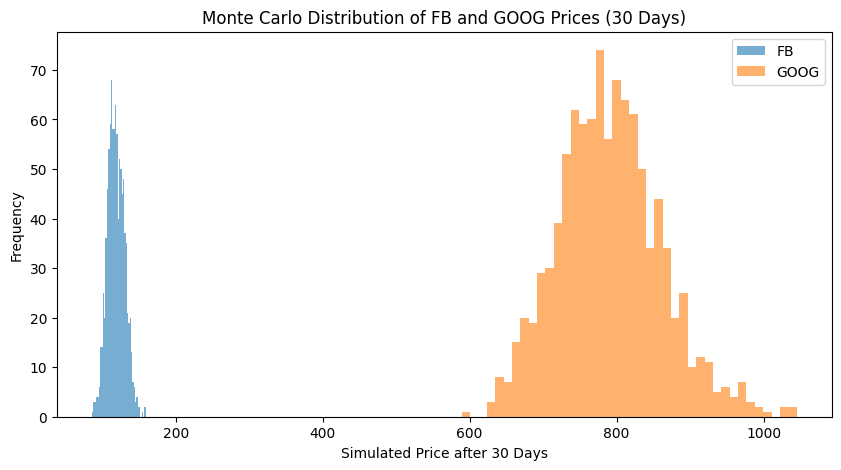

Based on the Monte Carlo histograms, FB exhibits higher volatility and a wider range of possible outcomes,
while GOOG shows a more concentrated distribution, indicating lower risk and more stable price behavior.
FB has slightly higher volatility in returns (std), while GOOG may show a wider spread in dollar prices due to its higher price level


In [6]:
# Task5: Compare the distribution of final simulated prices for FB and GOOG after 30 days using Monte Carlo simulation. 
# Run 1,000 simulations for each stock and visualize the results using histograms. Analyze which stock shows higher volatility and potential upside

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

simulations = 1000
days = 30

fb_last_price = df["FB"].iloc[-1]
goog_last_price = df["GOOG"].iloc[-1]

fb_final_prices = []
goog_final_prices = []

for i in range(simulations):
    fb_price = fb_last_price
    goog_price = goog_last_price
    
    for d in range(days):
        fb_return = np.random.normal(fb_mean, fb_std)
        goog_return = np.random.normal(goog_mean, goog_std)
        
        fb_price = fb_price * (1 + fb_return)
        goog_price = goog_price * (1 + goog_return)
    
    fb_final_prices.append(fb_price)
    goog_final_prices.append(goog_price)


plt.figure(figsize=(10, 5))
plt.hist(fb_final_prices, bins=40, alpha=0.6, label="FB")
plt.hist(goog_final_prices, bins=40, alpha=0.6, label="GOOG")
plt.xlabel("Simulated Price after 30 Days")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of FB and GOOG Prices (30 Days)")
plt.legend()
plt.show()

print(
    "Based on the Monte Carlo histograms, FB exhibits higher volatility and a wider range of "
    "possible outcomes,\nwhile GOOG shows a more concentrated distribution, indicating lower "
    "risk and more stable price behavior.\nFB has slightly higher volatility in returns (std), "
    "while GOOG may show a wider spread in dollar prices due to its higher price level"
)

In [7]:
# Task6: Perform a power analysis to determine the minimum number of days required to detect a statistically significant difference in mean daily returns 
# between FB and GOOG with 80% power and a significance level of 0.05

from scipy.stats import ttest_ind
from statsmodels.stats.power import TTestIndPower

np.random.seed(42)

alpha = 0.05
target_power = 0.80

simulations = 500
sample_sizes = range(30, 3001, 30) 

found = False
best_n = None
best_power = None

for n in sample_sizes:
    significant = 0

    for _ in range(simulations):
        fb_sample = np.random.normal(fb_mean, fb_std, size=n)
        goog_sample = np.random.normal(goog_mean, goog_std, size=n)

        _, p_value = ttest_ind(fb_sample, goog_sample, equal_var=False)

        if p_value < alpha:
            significant += 1

    power = significant / simulations
    best_n = n
    best_power = power

    if power >= target_power:
        found = True
        break

print("Simulation-based power analysis")
if found:
    print("Minimum number of days required (per stock):", best_n)
    print("Achieved power:", best_power)
else:
    print("80% power was NOT reached up to", best_n, "days.")
    print("Power at", best_n, "days was:", best_power)

pooled_std = np.sqrt((fb_std**2 + goog_std**2) / 2.0)
effect_size = abs(fb_mean - goog_mean) / pooled_std

analysis = TTestIndPower()
required_n = analysis.solve_power(effect_size=effect_size, power=target_power, alpha=alpha)

print("\nAnalytical check (TTestIndPower)")
print("Estimated effect size (Cohen's d):", effect_size)
print("Sample size per group needed for 80% power (theoretical):", int(np.ceil(required_n)))

print("\nConclusion")
if found:
    print(
        "The mean return difference is detectable with 80% power at this sample size.\n"
        f"Simulation reached 80% power at about {best_n} days per stock"
    )
else:
    print(
        "The simulation did not reach 80% power up to 3000 days.\n" 
        "The analytical check estimates an extremely large required sample size, which confirms that the\n" 
        "difference in mean daily returns between FB and GOOG is very small compared to daily volatility.\n" 
        "Therefore, detecting this mean difference with 80% power is impractical with a typical dataset size"
    )


Simulation-based power analysis
80% power was NOT reached up to 3000 days.
Power at 3000 days was: 0.044

Analytical check (TTestIndPower)
Estimated effect size (Cohen's d): 0.0008601499056367908
Sample size per group needed for 80% power (theoretical): 21217213

Conclusion
The simulation did not reach 80% power up to 3000 days.
The analytical check estimates an extremely large required sample size, which confirms that the
difference in mean daily returns between FB and GOOG is very small compared to daily volatility.
Therefore, detecting this mean difference with 80% power is impractical with a typical dataset size


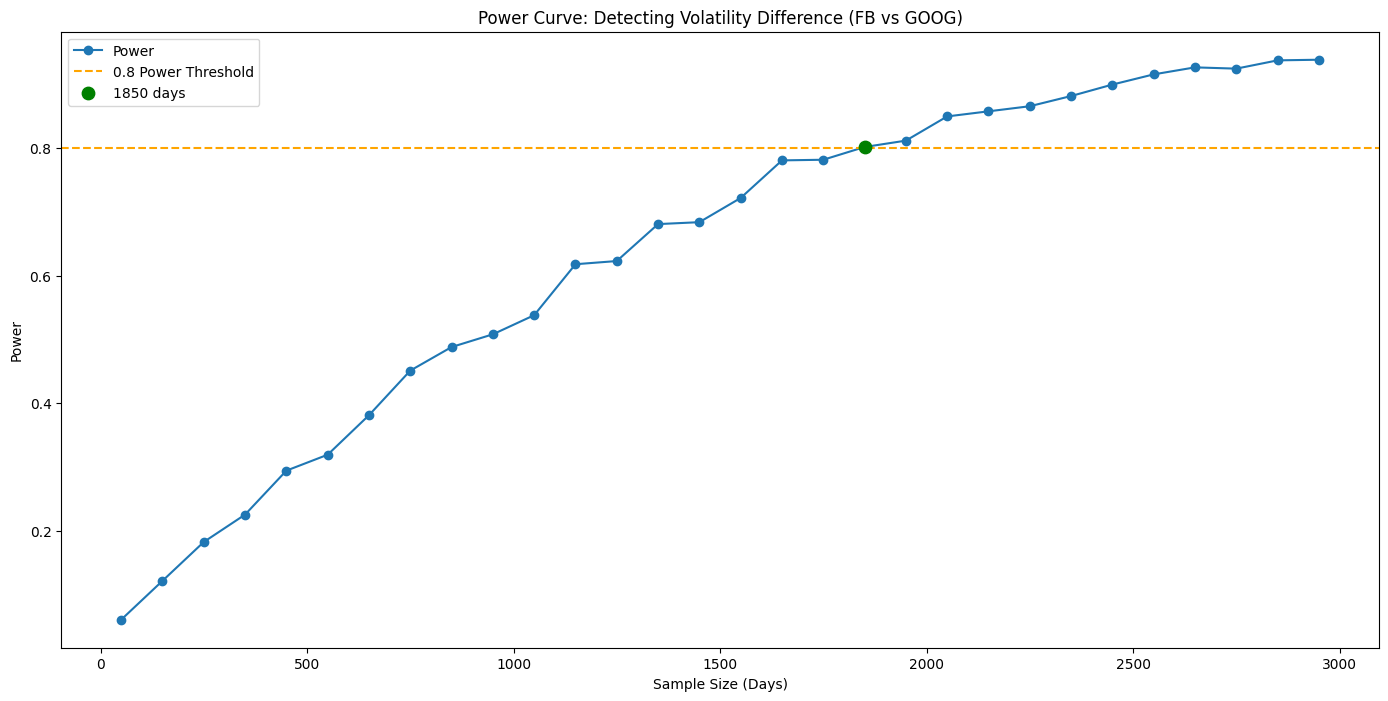

Max power in tested range: 0.939
Power first exceeds 0.8 at: 1850 days
The power curve shows that the ability to detect a difference in volatility between FB and GOOG
increases with sample size. The 0.8 power threshold is reached at 1850 days,
indicating that a large number of observations is required.


In [8]:
# Task7: Simulate the effect of increasing sample size on the power of detecting a difference in volatility between FB and GOOG daily returns. 
# Plot the power curve and interpret the results

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levene

np.random.seed(42)

alpha = 0.05
simulations = 1000
max_days = 3000
step = 100

sample_sizes = list(range(50, max_days + 1, step))
powers = []

for n in sample_sizes:
    significant = 0

    for _ in range(simulations):
        fb_sample = np.random.normal(fb_mean, fb_std, n)
        goog_sample = np.random.normal(goog_mean, goog_std, n)

        _, p_value = levene(fb_sample, goog_sample)
        if p_value < alpha:
            significant += 1

    powers.append(significant / simulations)

intersection_day = None
intersection_power = None

for n, p in zip(sample_sizes, powers):
    if p >= 0.8:
        intersection_day = n
        intersection_power = p
        break

plt.figure(figsize=(17, 8))
plt.plot(sample_sizes, powers, marker="o", label="Power")
plt.axhline(0.8, linestyle="--", color="orange", label="0.8 Power Threshold")

if intersection_day is not None:
    plt.scatter(intersection_day, intersection_power, color="green", s=80, zorder=5,
                label=f"{intersection_day} days")


plt.xlabel("Sample Size (Days)")
plt.ylabel("Power")
plt.title("Power Curve: Detecting Volatility Difference (FB vs GOOG)")
plt.legend()
plt.show()

print("Max power in tested range:", max(powers))

if intersection_day is not None:
    print("Power first exceeds 0.8 at:", intersection_day, "days")
else:
    print("Power does not reach 0.8 within the tested range")

print(
    "The power curve shows that the ability to detect a difference in volatility between FB and GOOG\n"
    "increases with sample size. The 0.8 power threshold is reached at "
    f"{intersection_day} days,\nindicating that a large number of observations is required."
)


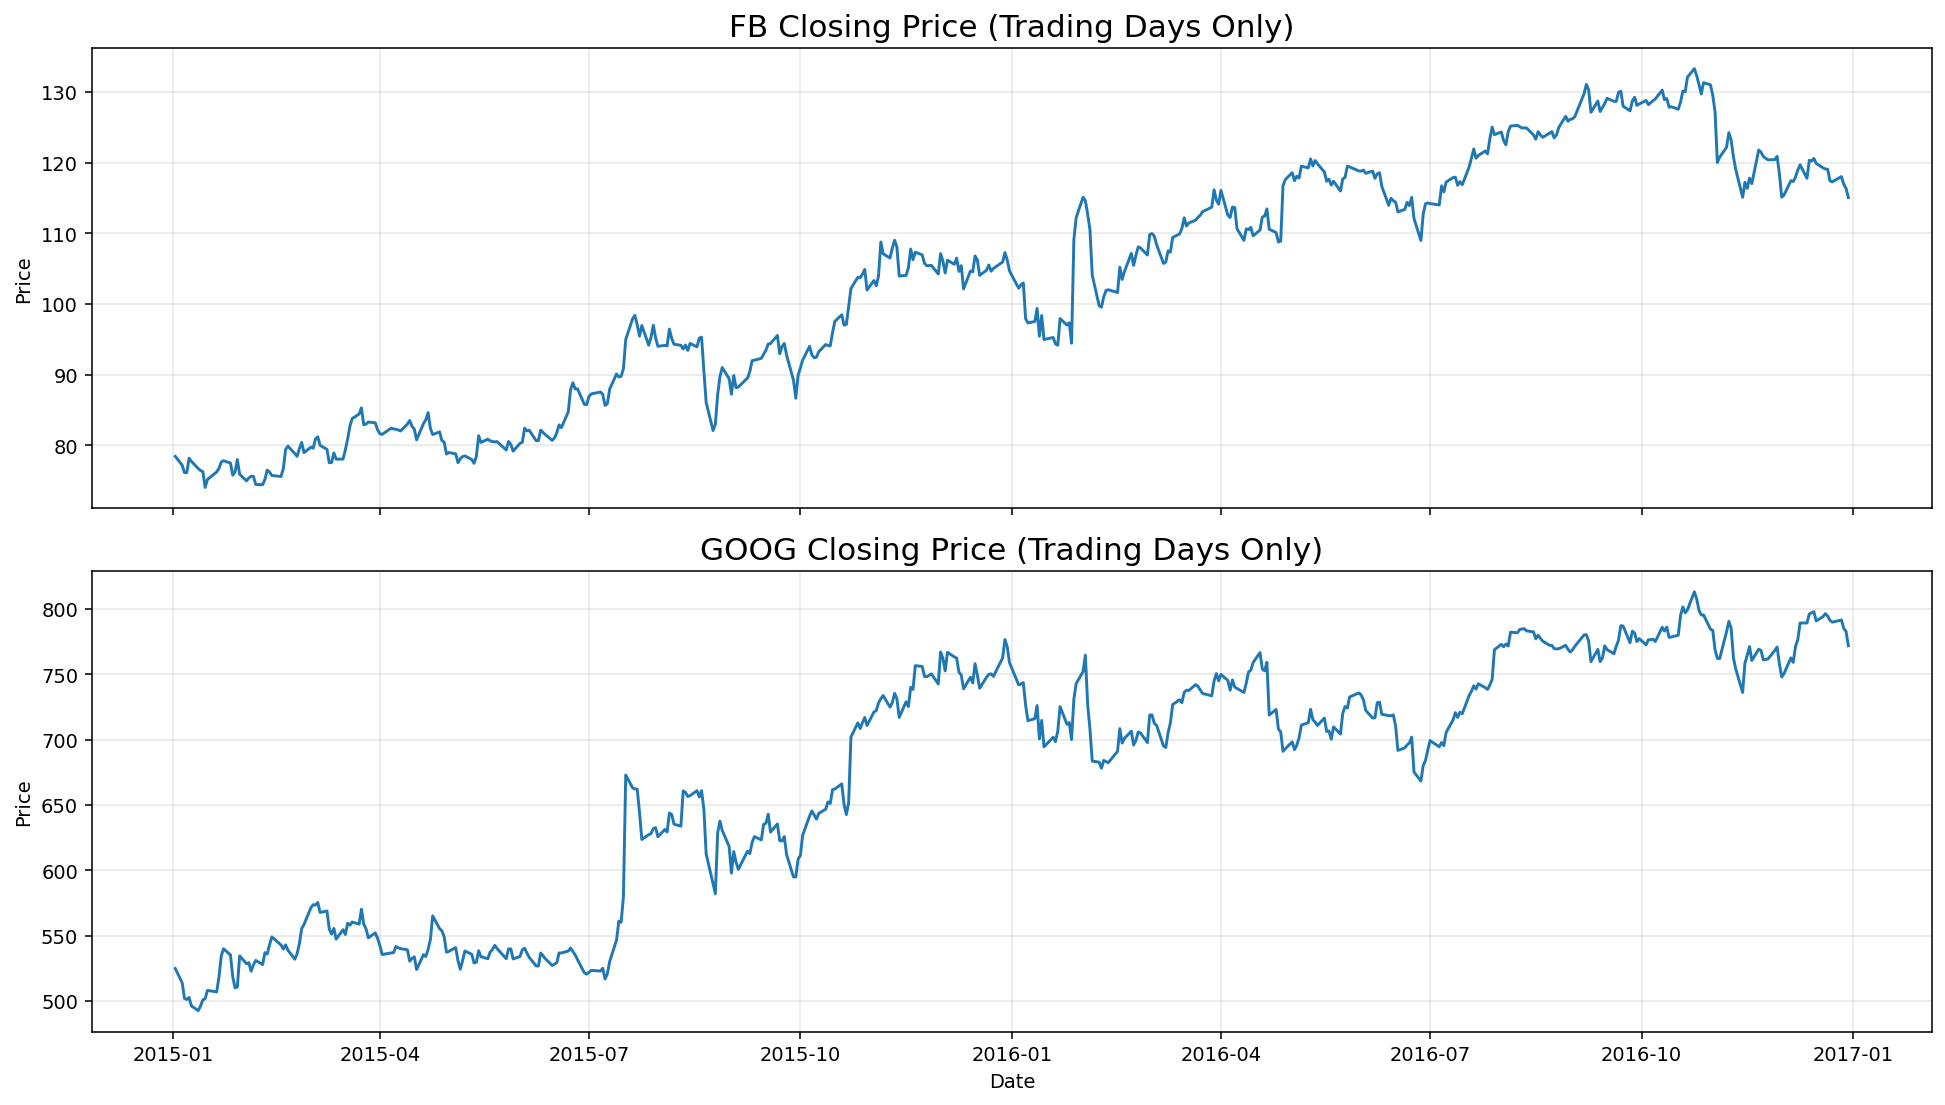

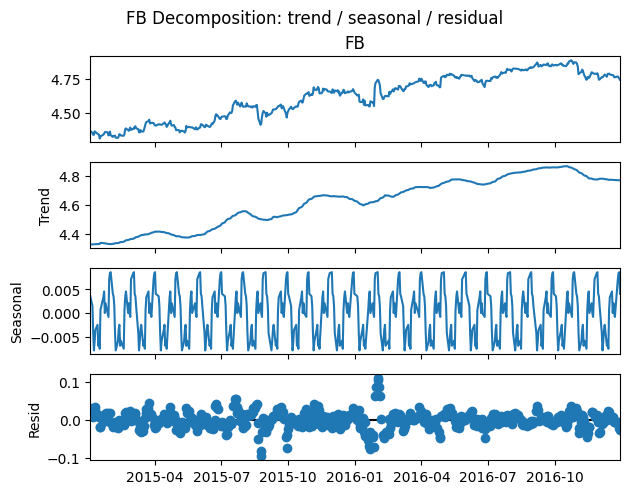

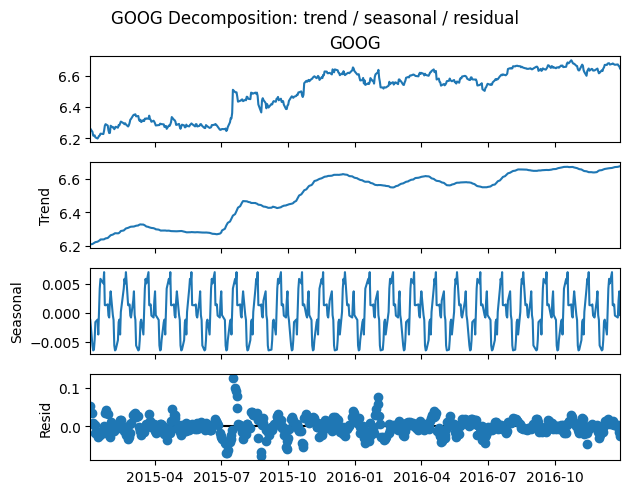

Seasonality strength (std of seasonal component, log scale)
FB seasonal std: 0.005017955095540236
GOOG seasonal std: 0.0038199492477595325

Discussion
Trend:
 - Both stocks show a clear trend over time, so prices are non-stationary

Seasonality:
 - We use period=21 to approximate a monthly cycle in trading days
 - The seasonal component is small compared to the trend and residual noise, so seasonality is weak

Residuals:
 - Residuals are noisy with occasional spikes (market shocks/news), which limits short-term predictability

Implications for forecasting:
 - Forecasting raw prices is hard because trend + noise dominate
 - A common approach is to difference prices (or model log-returns) and apply ARIMA
 - Since seasonality is small, seasonal models may add limited improvement here


In [9]:
# Task8: Visualize the time series of FB and GOOG closing prices. Apply decomposition to separate trend, seasonality, and residuals. 
# Discuss the observed patterns and their implications for forecasting

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("FB_GOOG_Historical_Prices_2015_2016.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

fb = df["FB"].dropna()
goog = df["GOOG"].dropna()

fig, ax = plt.subplots(2, 1, figsize=(14, 8), dpi=140, sharex=True)

ax[0].plot(fb.index, fb.values)
ax[0].set_title("FB Closing Price (Trading Days Only)", fontsize=16)
ax[0].set_ylabel("Price")
ax[0].grid(True, alpha=0.3)

ax[1].plot(goog.index, goog.values)
ax[1].set_title("GOOG Closing Price (Trading Days Only)", fontsize=16)
ax[1].set_ylabel("Price")
ax[1].set_xlabel("Date")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

period = 21  

fb_log = np.log(fb)
goog_log = np.log(goog)

fb_dec = seasonal_decompose(fb_log, model="additive", period=period, extrapolate_trend="freq")
goog_dec = seasonal_decompose(goog_log, model="additive", period=period, extrapolate_trend="freq")

fb_dec.plot()
plt.suptitle("FB Decomposition: trend / seasonal / residual", y=1.02)
plt.show()

goog_dec.plot()
plt.suptitle("GOOG Decomposition: trend / seasonal / residual", y=1.02)
plt.show()

print("Seasonality strength (std of seasonal component, log scale)")
print("FB seasonal std:", float(fb_dec.seasonal.std()))
print("GOOG seasonal std:", float(goog_dec.seasonal.std()))

print("\nDiscussion")
print("Trend:")
print(" - Both stocks show a clear trend over time, so prices are non-stationary\n")

print("Seasonality:")
print(" - We use period=21 to approximate a monthly cycle in trading days")
print(" - The seasonal component is small compared to the trend and residual noise, so seasonality is weak\n")

print("Residuals:")
print(" - Residuals are noisy with occasional spikes (market shocks/news), which limits short-term predictability\n")

print("Implications for forecasting:")
print(" - Forecasting raw prices is hard because trend + noise dominate")
print(" - A common approach is to difference prices (or model log-returns) and apply ARIMA")
print(" - Since seasonality is small, seasonal models may add limited improvement here")


Best ARIMA order (by AIC): (1, 1, 4)
Best AIC: 1958.4255360341367

FB forecast for next 10 days (ARIMA):
Day 1: $115.3072
Day 2: $115.4301
Day 3: $115.6321
Day 4: $115.6597
Day 5: $115.6367
Day 6: $115.6558
Day 7: $115.6399
Day 8: $115.6532
Day 9: $115.6421
Day 10: $115.6513


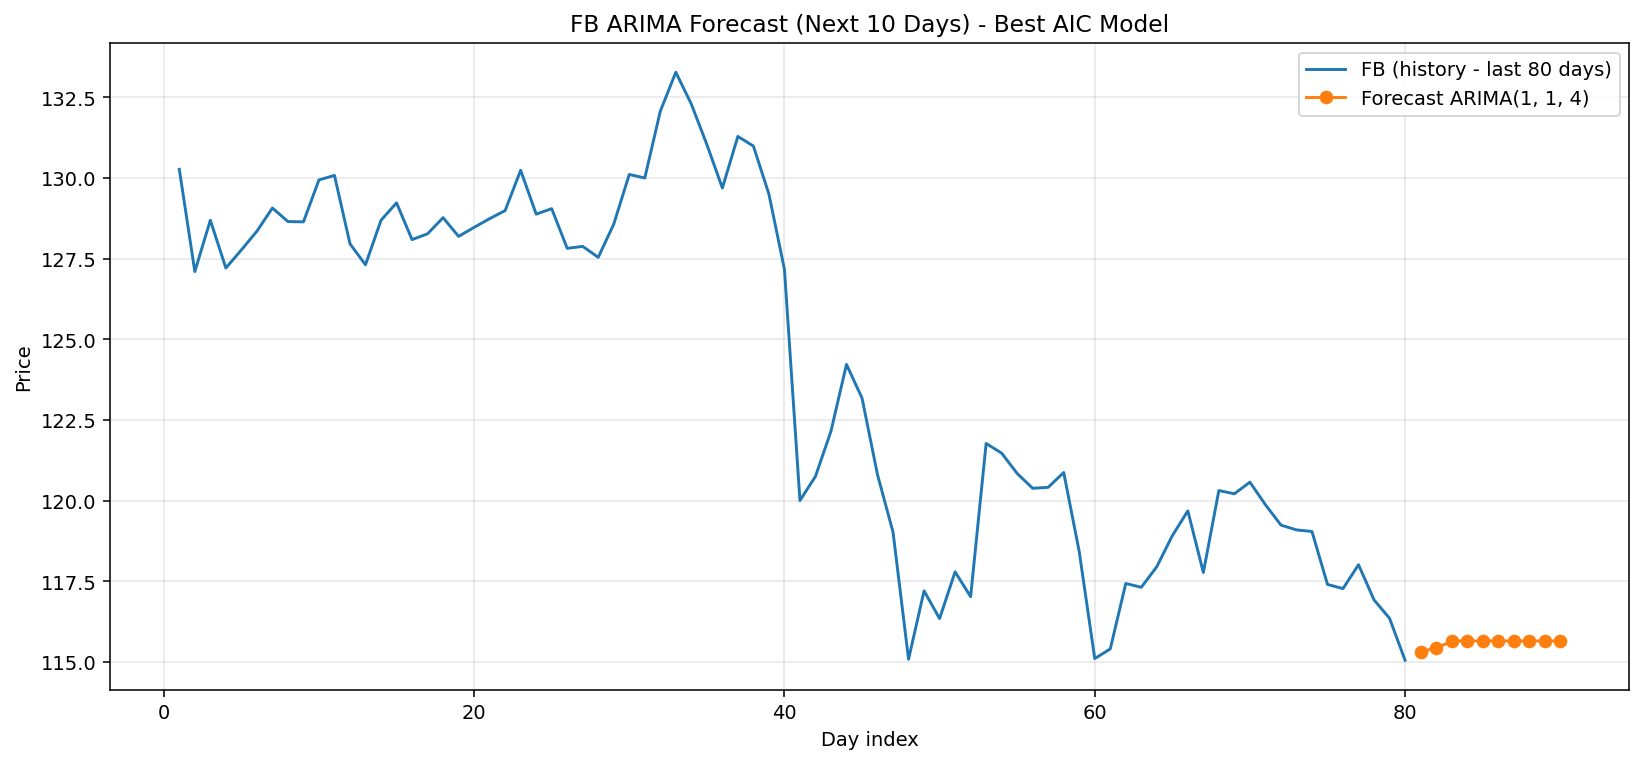


ARIMA(1, 1, 4) was selected as the best model because it has the lowest AIC among converged models.
We forecast 10 days ahead


In [10]:
# Task9: Use an ARIMA model to forecast FB stock prices for the next 10 days

import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

df = pd.read_csv("FB_GOOG_Historical_Prices_2015_2016.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

fb = df["FB"].dropna()

fb_values = fb.copy()
fb_values.index = range(len(fb_values))

p_values = range(0, 6)
d_values = range(0, 3)
q_values = range(0, 6)

best_aic = np.inf
best_order = None
best_res = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            if p == 0 and d == 0 and q == 0:
                continue
            try:
                res = ARIMA(fb_values, order=(p, d, q)).fit()

                if not res.mle_retvals.get("converged", True):
                    continue

                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, d, q)
                    best_res = res

            except Exception:
                pass

print("Best ARIMA order (by AIC):", best_order)
print("Best AIC:", best_aic)

steps = 10
forecast = best_res.forecast(steps=steps)

print("\nFB forecast for next 10 days (ARIMA):")
for i, val in enumerate(forecast.values, start=1):
    print(f"Day {i}: ${val:.4f}")

plt.figure(figsize=(14, 6), dpi=140)
plt.plot(range(1, 81), fb.iloc[-80:].values, label="FB (history - last 80 days)")
plt.plot(range(81, 81 + steps), forecast.values, marker="o", label=f"Forecast ARIMA{best_order}")
plt.title("FB ARIMA Forecast (Next 10 Days) - Best AIC Model")
plt.xlabel("Day index")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"\nARIMA{best_order} was selected as the best model because it has the lowest AIC among converged models.")
print("We forecast 10 days ahead")


GOOG forecast for next 10 days (Exponential Smoothing):
Day 1: $769.2283
Day 2: $767.1183
Day 3: $767.5344
Day 4: $768.1392
Day 5: $769.8855
Day 6: $772.3903
Day 7: $773.5491
Day 8: $772.0099
Day 9: $775.1126
Day 10: $778.1067


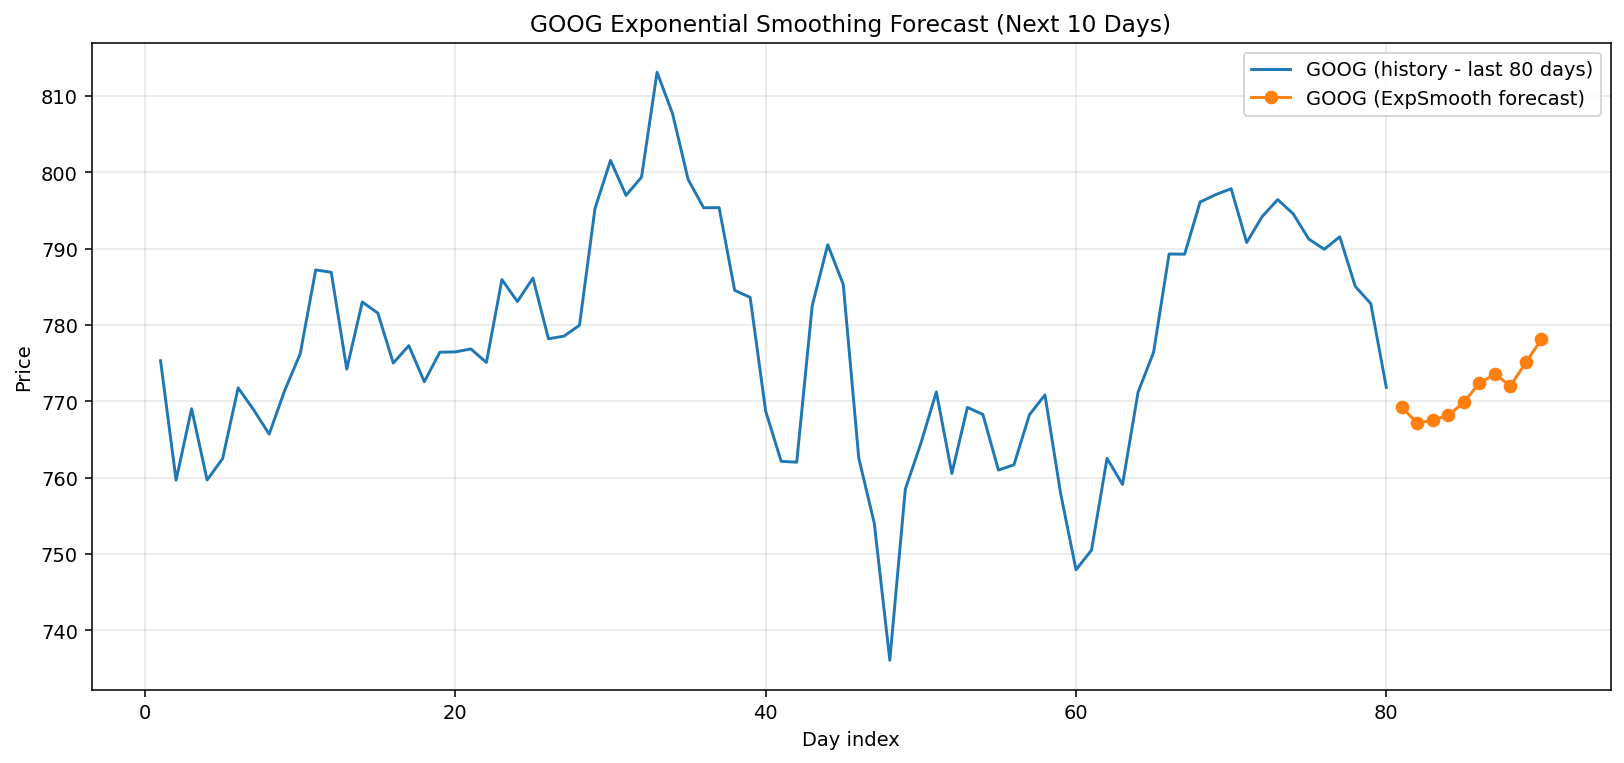

In [11]:
# Task10: Use an Exponential Smoothing forecast for GOOG stock prices over the next 10 days

from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("FB_GOOG_Historical_Prices_2015_2016.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

goog = df["GOOG"].dropna()

goog_values = goog.copy()
goog_values.index = range(len(goog_values))

model = ExponentialSmoothing(
    goog_values,
    trend="add",
    seasonal="add",
    seasonal_periods=21,
    initialization_method="estimated"
)

fit = model.fit(optimized=True)
forecast = fit.forecast(10) 

print("GOOG forecast for next 10 days (Exponential Smoothing):")
for i, val in enumerate(forecast.values, start=1):
    print(f"Day {i}: ${val:.4f}")

plt.figure(figsize=(14, 6), dpi=140)

hist_y = goog.iloc[-80:].values
hist_x = list(range(1, 81))
plt.plot(hist_x, hist_y, label="GOOG (history - last 80 days)")

fc_x = list(range(81, 81 + 10))
plt.plot(fc_x, forecast.values, marker="o", label="GOOG (ExpSmooth forecast)")

plt.title("GOOG Exponential Smoothing Forecast (Next 10 Days)")
plt.xlabel("Day index")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()